In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import keras_tuner as kt
import tensorflow as tf  
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.models import load_model

In [ ]:
pip install tensorflow

In [2]:
# =========================================================
# 1️⃣ Load and prepare data
# =========================================================
df = pd.read_csv("daily_market_topic_sentiment_price.csv")


In [3]:
# Create new column: price change vs previous day
df["price_change_vs_T_minus_1"] = df["T_price"] - df["T_minus_1_price"]

df["date"] = pd.to_datetime(df["datetime"].astype(str), format="%Y%m%d")

# Drop the first row (since it has NaN in T_minus_1_price)
df = df.dropna(subset=["T_minus_1_price"]).reset_index(drop=True)


In [4]:
df.head()

,Unnamed: 0,close,adjclose,volume,datetime,ticker,T_minus_1_price,T_price,change_vs_T_minus_1,topic_0,...,topic_4,topic_5,topic_6,topic_7,topic_8,min_sentiment,max_sentiment,avg_sentiment,price_change_vs_T_minus_1,date
0,1,1.588667,1.588667,257806500,20100630,TSLA,1.592667,1.588667,0,0.000444,...,0.028483,0.011951,0.000444,0.182969,0.032154,-0.9866,0.9225,-0.032050,-0.004000,2010-06-30
1,2,1.464000,1.464000,123282000,20100701,TSLA,1.588667,1.464000,0,0.009303,...,0.108627,0.013985,0.002795,0.098501,0.000862,-0.9938,0.9998,0.357357,-0.124667,2010-07-01
2,3,1.280000,1.280000,77097000,20100702,TSLA,1.464000,1.280000,0,0.021416,...,0.024236,0.000402,0.003236,0.141207,0.022699,-0.9800,0.9997,0.319300,-0.184000,2010-07-02
3,4,1.074000,1.074000,103003500,20100706,TSLA,1.280000,1.074000,0,0.003680,...,0.174809,0.135488,0.000381,0.272162,0.000381,-0.9942,0.9877,-0.003250,-0.206000,2010-07-06
4,5,1.053333,1.053333,103825500,20100707,TSLA,1.074000,1.053333,0,0.064868,...,0.000365,0.120344,0.345490,0.045399,0.000364,0.9973,0.9973,0.997300,-0.020667,2010-07-07


**Data Split (Train/Val/Split)**

In [ ]:
# ====================================================
# 2️⃣ DEFINE SPLIT RANGES (Updated for modern Tesla regime)
# ====================================================
TRAIN_START = pd.to_datetime("2018-01-01").date()
TRAIN_END   = pd.to_datetime("2022-12-31").date()

VAL_START   = pd.to_datetime("2023-01-01").date()
VAL_END     = pd.to_datetime("2023-12-31").date()

TEST_START  = pd.to_datetime("2024-01-01").date()
TEST_END    = pd.to_datetime("2025-04-14").date()


In [6]:
# ====================================================
# 6. ASSIGN SPLIT LABEL
# ====================================================
def get_split(d):
    if TRAIN_START <= d <= TRAIN_END:
        return "train"
    elif VAL_START <= d <= VAL_END:
        return "val"
    elif TEST_START <= d <= TEST_END:
        return "test"
    else:
        return "exclude"

# ====================================================
# 3️⃣ Apply split assignment
# ====================================================
df["split"] = df["date"].apply(lambda x: get_split(pd.to_datetime(x).date()))

# ====================================================
# 4️⃣ Drop rows with split = "exclude"
# ====================================================
df = df[df["split"] != "exclude"].reset_index(drop=True)



In [7]:
df.head()

,Unnamed: 0,close,adjclose,volume,datetime,ticker,T_minus_1_price,T_price,change_vs_T_minus_1,topic_0,...,topic_5,topic_6,topic_7,topic_8,min_sentiment,max_sentiment,avg_sentiment,price_change_vs_T_minus_1,date,split
0,1752,21.368668,21.368668,65283000,20180102,TSLA,20.756666,21.368668,1,0.000550,...,0.813569,0.000551,0.000550,0.182578,-0.9626,-0.9626,-0.962600,0.612001,2018-01-02,train
1,1753,21.105333,21.105333,68868000,20180105,TSLA,20.974667,21.105333,1,0.000416,...,0.008761,0.000417,0.189001,0.000416,0.9960,0.9960,0.996000,0.130667,2018-01-05,train
2,1754,22.427334,22.427334,147891000,20180108,TSLA,21.105333,22.427334,1,0.014210,...,0.324501,0.020286,0.188947,0.048538,-0.9988,0.9916,0.138767,1.322001,2018-01-08,train
3,1755,22.246000,22.246000,107199000,20180109,TSLA,22.427334,22.246000,0,0.013984,...,0.318975,0.000335,0.240559,0.141643,0.9616,0.9792,0.970400,-0.181334,2018-01-09,train
4,1756,22.320000,22.320000,64648500,20180110,TSLA,22.246000,22.320000,1,0.006775,...,0.156974,0.016369,0.188109,0.341026,-0.9925,0.9997,0.600180,0.073999,2018-01-10,train


**1. Training for Classification**

In [8]:
# Select input and output columns
# features = ['volume', 'T_minus_1_price', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 
#             'topic_4', 'topic_5', 'topic_6', 'topic_7', 
#             'min_sentiment', 'max_sentiment', 'avg_sentiment']
features = ['topic_0', 'topic_1', 'topic_2', 'topic_3', 
            'topic_4', 'topic_5', 'topic_6', 'topic_7', 
            'min_sentiment', 'max_sentiment', 'avg_sentiment']
target = 'change_vs_T_minus_1'

In [9]:
# ====================================================
# 2️⃣ Prepare X and y
# ====================================================
X = df[features].fillna(0)
y = df[target].fillna(0)

# ====================================================
# 3️⃣ Split by your predefined 'split' column
# ====================================================
X_train = X[df['split'] == 'train']
y_train = y[df['split'] == 'train']

X_val = X[df['split'] == 'val']
y_val = y[df['split'] == 'val']

X_test = X[df['split'] == 'test']
y_test = y[df['split'] == 'test']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1164, 11), Val: (240, 11), Test: (320, 11)


In [10]:
# Standardize input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
# =========================================================
# 2️⃣ Define learning rate schedule (warm-up ratio)
# =========================================================
initial_lr = 1e-4
warmup_ratio = 0.1
total_epochs = 20

def lr_schedule(epoch):
    if epoch < warmup_ratio * total_epochs:
        return initial_lr * (epoch + 1) / (warmup_ratio * total_epochs)
    else:
        return initial_lr * np.exp(-0.2 * (epoch - warmup_ratio * total_epochs))

In [31]:
pip install keras-tuner -q

Note: you may need to restart the kernel to use updated packages.


**a. Hyperparams Tuning**

In [ ]:
# =========================================================
# 3️⃣ Define the Hypermodel Function
# =========================================================
# This function will be called by KerasTuner to build and compile models
def build_model(hp):
    model = Sequential()
    
    # === Tune Model Architecture ===
    # Tune the number of units in the first layer
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    
    # Tune the dropout rate (around your 0.2-0.3 range)
    hp_dropout = hp.Choice('dropout_rate', [0.2, 0.3, 0.4])

    # Tune the number of hidden layers (1-4 is more reasonable than 10)
    hp_num_layers = hp.Int('num_layers', 1, 4)

    # Input Layer
    model.add(Dense(units=hp_units, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dropout(hp_dropout))

    # Hidden Layers
    for i in range(hp_num_layers - 1): # We already added one layer
        # For subsequent layers, we can halve the number of units
        hp_units = hp.Int(f'units_{i}', min_value=16, max_value=128, step=16)
        model.add(Dense(units=hp_units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(hp_dropout))

    # Output Layer (for binary classification)
    model.add(Dense(1, activation='sigmoid'))

    # === Tune Optimizer Hyperparameters ===
    # Tune Learning Rate (around your 1e-4)
    hp_learning_rate = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4, 5e-5])
    
    # Tune Weight Decay (around your 1e-4)
    hp_weight_decay = hp.Choice('weight_decay', [1e-3, 1e-4, 1e-5, 0.0])

    optimizer = AdamW(
        learning_rate=hp_learning_rate, 
        weight_decay=hp_weight_decay
    )

    # === Compile with the CORRECT Loss and Metrics ===
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy', # ✅ CORRECT loss for classification
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # ✅ CORRECT metrics
    )
    
    return model

# =========================================================
# 4️⃣ Instantiate the Tuner (Hyperband)
# =========================================================
# Hyperband is an efficient algorithm that uses early-stopping
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Optimize for validation AUC
    max_epochs=20,          # Max epochs to train one model (like your total_epochs)
    factor=3,               # Reduction factor for epochs and models
    directory='market_news_hyperparam_tuning', # Folder to store results
    project_name='price_prediction'
)

# Define an EarlyStopping callback to stop training individual models
# if they don't improve. This goes *inside* the tuner.search()
stop_early = EarlyStopping(monitor='val_loss', patience=4)

print("="*30)
print("Starting Hyperparameter Search...")
print("="*30)

# =========================================================
# 5️⃣ Run the Search
# =========================================================
# This will take time! It will train many models to find the best combination.
tuner.search(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    callbacks=[stop_early],
    verbose=1
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*30)
print(f"Optimal Hyperparameters Found:")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")
print(f"  Weight Decay:  {best_hps.get('weight_decay')}")
print(f"  Dropout Rate:  {best_hps.get('dropout_rate')}")
print(f"  Num Layers:    {best_hps.get('num_layers')}")
print(f"  First Layer Units: {best_hps.get('units')}")
print("="*30 + "\n")

# =========================================================
# 6️⃣ Get the Best Model and Evaluate
# =========================================================
# Get the best model (already trained on the best epoch)
# directly from the tuner.
best_model = tuner.get_best_models(num_models=1)[0]

print("Evaluating best model on Test Set:")
loss, accuracy, auc = best_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Test Loss: {loss:.6f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test AUC: {auc:.4f}")

# =========================================================
# 7️⃣ Show Final Classification Report
# =========================================================
# Get predictions (probabilities)
y_pred_probs = best_model.predict(X_test_scaled)
# Convert probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("\n" + "="*30)
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))
print("="*30)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)
print("="*30)

Trial 30 Complete [00h 00m 02s]
val_auc: 0.5427972078323364

Best val_auc So Far: 0.5985664129257202
Total elapsed time: 00h 00m 49s

Optimal Hyperparameters Found:
  Learning Rate: 0.001
  Weight Decay:  0.001
  Dropout Rate:  0.2
  Num Layers:    2
  First Layer Units: 192

Evaluating best model on Test Set:
✅ Test Loss: 0.696187
✅ Test Accuracy: 0.5000
✅ Test AUC: 0.5051
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.53      0.28      0.37       166
     Class 1       0.49      0.74      0.59       154

    accuracy                           0.50       320
   macro avg       0.51      0.51      0.48       320
weighted avg       0.51      0.50      0.47       320

Confusion Matrix:
[[ 46 120]
 [ 40 114]]


**b. Train with hyperparam value from best trial**

In [ ]:
# =========================================================
# 2. Optimal Hyperparameters from our Trial
# =========================================================
OPTIMAL_LR = 0.001
OPTIMAL_WD = 0.001
OPTIMAL_DROPOUT = 0.2

# This model now has 2 hidden layers, starting with 192 units.
model = Sequential([
    # Layer 1 (First Layer Units: 192)
    Dense(192, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),

    # Layer 2 (Num Layers: 2)
    Dense(96, activation='relu'), # Assuming halving: 192 -> 96
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.summary()

# =========================================================
# 4️⃣ Compile model (AdamW optimizer)
# =========================================================
optimizer = AdamW(
    learning_rate=OPTIMAL_LR, 
    weight_decay=OPTIMAL_WD
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy', # ✅ Use the correct loss for classification
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# =========================================================
# 5️⃣ Combine Train + Val data for final training
# =========================================================
X_train_full = np.concatenate([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

# =========================================================
# 6️⃣ Calculate Class Weights to fix bias
# =========================================================
# This will force the model to pay more attention to the
# minority class, which it was ignoring before.
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weights = dict(enumerate(weights))
print(f"Using Class Weights to fight imbalance: {class_weights}")

# =========================================================
# 7️⃣ Train model
# =================================0========================
# We train on the full (Train + Val) dataset
history = model.fit(
    X_train_full, y_train_full,
    epochs=50, # Train for a solid number of epochs
    batch_size=32,
    class_weight=class_weights, # ✅ Apply the weights
    callbacks=[
        EarlyStopping(
            monitor='loss', # Monitor training loss
            patience=5, 
            restore_best_weights=True
        )
    ],
    verbose=1
)

# =========================================================
# 8️⃣ Evaluate
# =========================================================
print("\n" + "="*30)
print("Evaluating Final Model on Test Set:")
loss, accuracy, auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Test Loss: {loss:.6f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test AUC: {auc:.4f}")

# Classification Report
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))
print("="*30)

/Users/dauvudangkhoi/Document/Text_Analytics/crawl/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 192)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 576 (2.25 KB)

Using Class Weights to fight imbalance: {0: np.float64(1.0556390977443608), 1: np.float64(0.9499323410013532)}
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.5171 - auc: 0.5234 - loss: 0.8366 
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - accuracy: 0.5242 - auc: 0.5312 - loss: 0.8006
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.5470 - auc: 0.5442 - loss: 0.7706
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - accuracy: 0.5634 - auc: 0.5802 - loss: 0.7354
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - accuracy: 0.5563 - auc: 0.5821 - loss: 0.7248
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.5527 - auc: 0.5781 - loss: 0.7225
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - accuracy: 0.5776 - auc: 0.6050 - loss: 0.6973
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.5798 - auc: 0.6144 - loss: 0.6923
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.5840 - auc: 0.6121 - l

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step


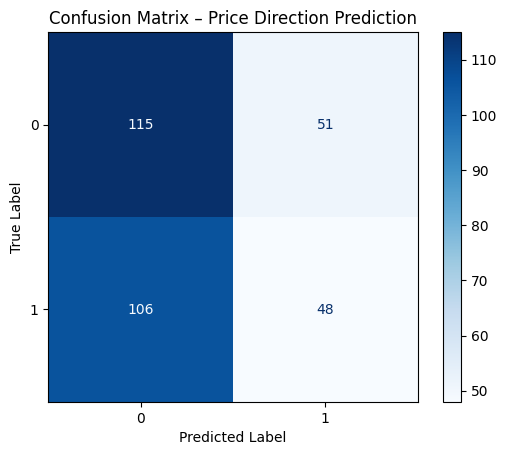

In [49]:
# =========================================================
# 1️⃣ Get model predictions
# =========================================================
# If binary classification (sigmoid output)
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# =========================================================
# 2️⃣ Generate confusion matrix
# =========================================================
cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)  # unique class labels (e.g., [0,1])

# =========================================================
# 3️⃣ Plot confusion matrix
# =========================================================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix – Price Direction Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


In [ ]:
# --- To Save ---
print("Saving model to HDF5 file...")
model.save('market_news_price_classifier_model.h5')
print("Model saved.")

# --- To Load it back later (in another script) ---
loaded_model = load_model('market_news_price_classifier_model.h5')

# Verify it's loaded correctly
loaded_model.summary()

Saving model to HDF5 file...
Model saved.


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 192)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,083 (86.27 KB)

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 2 (12.00 B)